In [1]:
import numpy as np, itertools
import tools21cm as t2c, numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

from scipy import special
from scipy.optimize import curve_fit
from scipy.special import jn
from scipy.special import jv
from scipy.integrate import quad
from tqdm import tqdm
from ipywidgets import interact

import astropy.units as u
import astropy.constants as cst
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import Angle

from scipy import stats

from matplotlib.colors import LogNorm

In [2]:
def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    """
    Simulated synchrotron emission. Simplified because of removed noise.
    """
    if(isinstance(z, float)):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)

    gf_data = np.zeros((ncells, ncells, z.size))

    if(rseed): 
        np.random.seed(rseed)
	
    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))
    nu_s,A150,beta_,a_syn,Da_syn = 150,513,2.34,2.8,0.1
	
    for i in range(0, z.size):
        nu = t2c.cosmo.z_to_nu(z[i])
        U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z[i])/boxsize
        l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
        C_syn = A150*(1000/l_cb)**beta_
        solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z[i])**2
        AA = np.sqrt(solid_angle*C_syn/2)
        T_four = AA*(X+Y*1j)
        T_real = np.abs(np.fft.ifft2(T_four))   #in Jansky
        gf_data[..., i] = t2c.telescope_functions.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
    
    return gf_data.squeeze(), l_cb

def telescope_beam_pattern(x, y, D=45, z=7):
    """
    Returns a 2D Gaussian array representing the telescope beam pattern.

    Parameters
    ----------
    x : ndarray
        Meshgrid x-coordinates.
    y : ndarray
        Meshgrid y-coordinates.
    D : float, optional
        Telescope dish diameter, in meters (default is 45).
    z : float, optional
        Redshift, which is converted to observation frequency (default is 7).

    Returns
    -------
    ndarray
        A 2D Gaussian array representing the telescope beam pattern.

    Notes
    -----
    The Gaussian array is calculated based on the provided dish diameter and redshift.
    """
    freq= t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6* fwhm
    return np.exp(-((x**2 + y**2) / theta_0**2))

def gaussian_source_2d(x, y, cov):
    """
    Covariance matrix takes two values which provided in arcseconds.
    """
    mean= np.array([0, 0]) #Mean
    #Covariance matrix:
    cov= np.array([[(cov[0]*u.arcsec).to('rad').value, 0], [0, (cov[1]*u.arcsec).to('rad').value]])
    
    x_diff = x- mean[0]
    y_diff = y- mean[1]
    
    inv_cov = np.linalg.inv(cov)

    exponent = -0.5 * (x_diff**2 *inv_cov[0,0] + y_diff**2 *inv_cov[1,1] + 2*x_diff*y_diff*inv_cov[0,1])
    prefactor = 1 / (2*np.pi*np.sqrt(np.linalg.det(cov)))

    return prefactor * np.exp(exponent)

def hirax_layout(N_ant, range):
    """
    Generates a square grid layout of antennas, similar to HIRAX.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).

    Returns
    -------
    ndarray
        An array containing the coordinates of the antennas arranged in a square grid.
        Each row represents the (x, y) coordinates of an antenna.
    """
    x= np.linspace(range[0], range[1], int(np.sqrt(N_ant)))
    X, Y= np.meshgrid(x, x)
    return np.dstack((X, Y)).reshape(-1, 2)

def random_layout(N_ant, range, seed):
    """
    Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X= np.random.uniform(range[0], range[1], N_ant)
    Y= np.random.uniform(range[0], range[1], N_ant)

    return np.dstack((X,Y)).reshape(-1, 2)

def median_index(list):
    """
    Returns the index of the median value in a numpy list.

    Parameters:
    - list: numpy array or list
        The input array containing numerical values.

    Returns:
    - int
        The index of the element closest to the median value.

    Raises:
    - ValueError: If the input list is empty.
    """
    average = np.mean(list)
    closest_index = np.abs(list - average).argmin()
    return closest_index

def arbitrary_index(list, value):
    closest_index = np.abs(list - value).argmin()
    return closest_index

def visibility_matrix_func(xyz_coord, lmn_coord, redshift, I_sky, beam_pattern):
    """
    Compute the visibility matrix for a given set of antennas and sky image.

    Parameters
    ----------
    xyz_coord : array_like
        Array of x, y, and z coordinates of antennas.
    lmn_coord : array_like
        Array of l, m, and n coordinates representing the direction of the sky image.
    redshift : float
        Redshift observed with 21-cm.
    I_sky : array_like
        Array containing the intensity of the sky image.
    beam_pattern : array_like
        Array representing the beam pattern of the telescope.

    Returns
    -------
    visibility_list : ndarray
        A 1D array of length N_B containing visibility values for each baseline.
    visibility_matrix : ndarray
        A 2D array representing the visibility matrix with shape (N_ant, N_ant).
    """
    N_ant= len(xyz_coord) #Number of antennas
    N_B= int(N_ant*(N_ant-1) / 2) #Number of baselines

    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c / freq

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas

    baseline_coord= np.empty((N_B, xyz_coord.shape[1])) #Initialize a baseline vectors array
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]

        #Calculate distance between antennas
        uv= ((xyz_coord[bb]- xyz_coord[aa]) / lam)
        baseline_coord[i]= uv

        #Calculate the fringe pattern
        fringe= np.exp(-2j * np.pi * (uv[0].value * lmn_coord[:,0] + uv[1].value * lmn_coord[:,1]))

        #Reshape fringe_pattern to match the shape of I_sky
        fringe_reshaped = fringe.reshape(I_sky.shape)

        #Calculate visibility for the current baseline
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)

        visibility_list[i]= visibility

        #Store the visibility value in the array
        visibility_matrix[aa, bb] = visibility
        visibility_matrix[bb, aa] = np.conj(visibility) #Visibility is symmetric

    return visibility_list, visibility_matrix, baseline_coord

def visibility_rotation_synthesis(lmn_coord, rotated_baselines, I_sky, beam_pattern, N_ant):
    N_B= int(N_ant*(N_ant-1) / 2)

    assert np.shape(rotated_baselines)[0] == N_B

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in range(N_B):
        aa, bb= pair_comb[i]
        uv= rotated_baselines[i]
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))
        fringe_reshaped = fringe.reshape(I_sky.shape)
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)
        visibility_list[i]= visibility

        visibility_matrix[aa, bb]=visibility
        visibility_matrix[bb, aa] = np.conj(visibility)

    return visibility_list, visibility_matrix

def Earth_Rotation_Effect(HA, delta):
    HA, delta = HA.to('rad').value, delta.to('rad').value
    
    return np.array([[np.sin(HA), np.cos(HA)], 
                     [-np.sin(delta)*np.cos(HA), np.sin(delta)*np.sin(HA)]])

def visibility_correlation_func(index, baseline_coord, visibility_list, N_B):
    """
    Computes visibility correlation and baseline distances from a given baseline index.

    Parameters:
    - index: int
        Index of the baseline vector.
    - baseline_coord: numpy.ndarray
        Array containing baseline coordinates.
    - visibility_list: numpy.ndarray
        Array containing visibility values.
    - N_B: int
        Total number of baseline vectors.

    Returns:
    - vis_corr: numpy.ndarray
        Array of visibility correlations.
    - baseline_distances_norm: numpy.ndarray
        Array of normalized baseline distances.
    """
    indices= np.linspace(0, N_B-1, N_B)
    indices_combinations= list(itertools.product([index], range(N_B))) #Generate combinations
    baseline_distances= np.empty((len(indices), 2)) #Create empty array for calculating distance between two vectors
    vis_corr= np.empty(len(indices), dtype=np.complex128)

    for i in range(len(indices)):
        ii, jj = indices_combinations[i]
        vis_corr[i]= visibility_list[ii] * np.conj(visibility_list[jj])
        baseline_distances[i]= baseline_coord[jj] - baseline_coord[ii]

    baseline_distances_norm= np.linalg.norm(baseline_distances, axis=1)

    return vis_corr.real, baseline_distances_norm

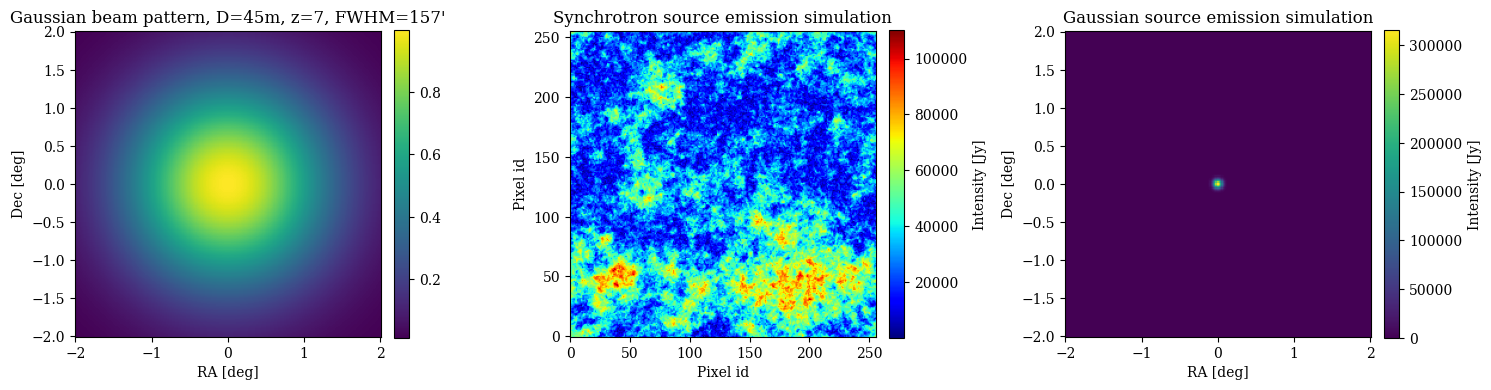

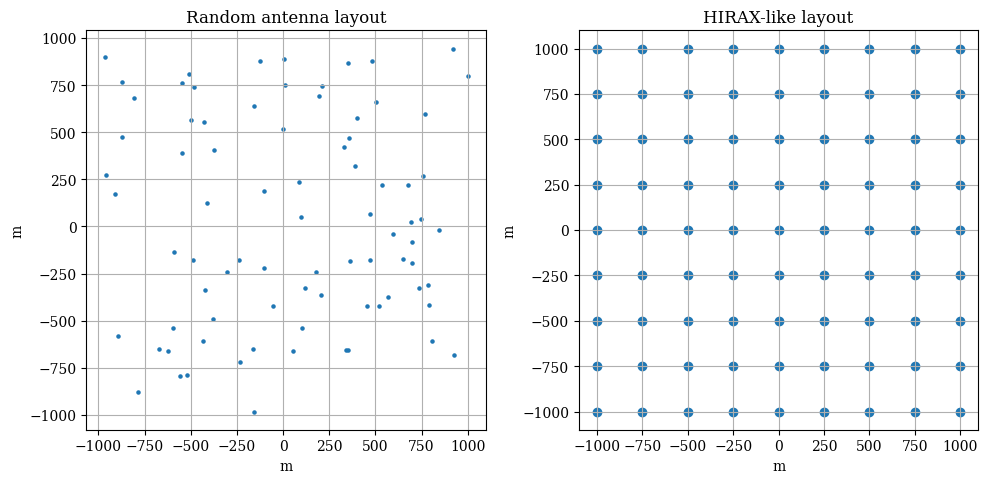

In [3]:
FoV= 4.*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 256).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
#Generate the coordinates of the telescope layout
xyz_grid= hirax_layout(9**2, [-1000., 1000.])
xyz_random= random_layout(9**2, [-1000, 1000], 2024)
#***********************************************

#Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
ang_dim_dist= FoV.to('rad').value * cosmo.angular_diameter_distance(rshift).value

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

beam_pattern= telescope_beam_pattern(l_coord, m_coord)
im0 = axes[0].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), beam_pattern, cmap='viridis')
axes[0].set_ylabel('Dec [deg]')
axes[0].set_xlabel('RA [deg]')
axes[0].set_title("Gaussian beam pattern, D=45m, z=7, FWHM=157'")
axes[0].set_box_aspect(1)
plt.colorbar(im0, fraction=0.046, pad=0.04)

synchro_source, l= galactic_synch_fg_custom(z=[rshift], ncells=len(thet), boxsize=256., rseed=2024)
im1 = axes[1].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[1].set_title("Synchrotron source emission simulation")
axes[1].set_ylabel('Pixel id')
axes[1].set_xlabel('Pixel id')
axes[1].set_box_aspect(1)
plt.colorbar(im1, label='Intensity [Jy]', fraction=0.046, pad=0.04)

gaussian_source= gaussian_source_2d(l_coord, m_coord, [0.1, 0.1])
im2 = axes[2].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, gaussian_source, cmap='viridis')
axes[2].set_title('Gaussian source emission simulation')
axes[2].set_ylabel('Dec [deg]')
axes[2].set_xlabel('RA [deg]')
axes[2].set_box_aspect(1)
plt.colorbar(im2, label='Intensity [Jy]', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

fig, axes= plt.subplots(1, 2, figsize=(10, 5))

axes[0].scatter(xyz_random[:, 0], xyz_random[:, 1], s=5)
axes[0].set_xlabel("m")
axes[0].set_ylabel("m")
axes[0].set_title("Random antenna layout")
axes[0].grid()
axes[0].set_box_aspect(1)

axes[1].scatter(xyz_grid[:,0], xyz_grid[:, 1])
axes[1].set_xlabel("m")
axes[1].set_ylabel("m")
axes[1].set_title("HIRAX-like layout")
axes[1].grid()
axes[1].set_box_aspect(1)

plt.tight_layout()
plt.show()

***
## __Plotting the visibility matrix and baselines correlations for a random and HIRAX-like layout.__

100%|██████████| 3240/3240 [00:22<00:00, 146.24it/s]


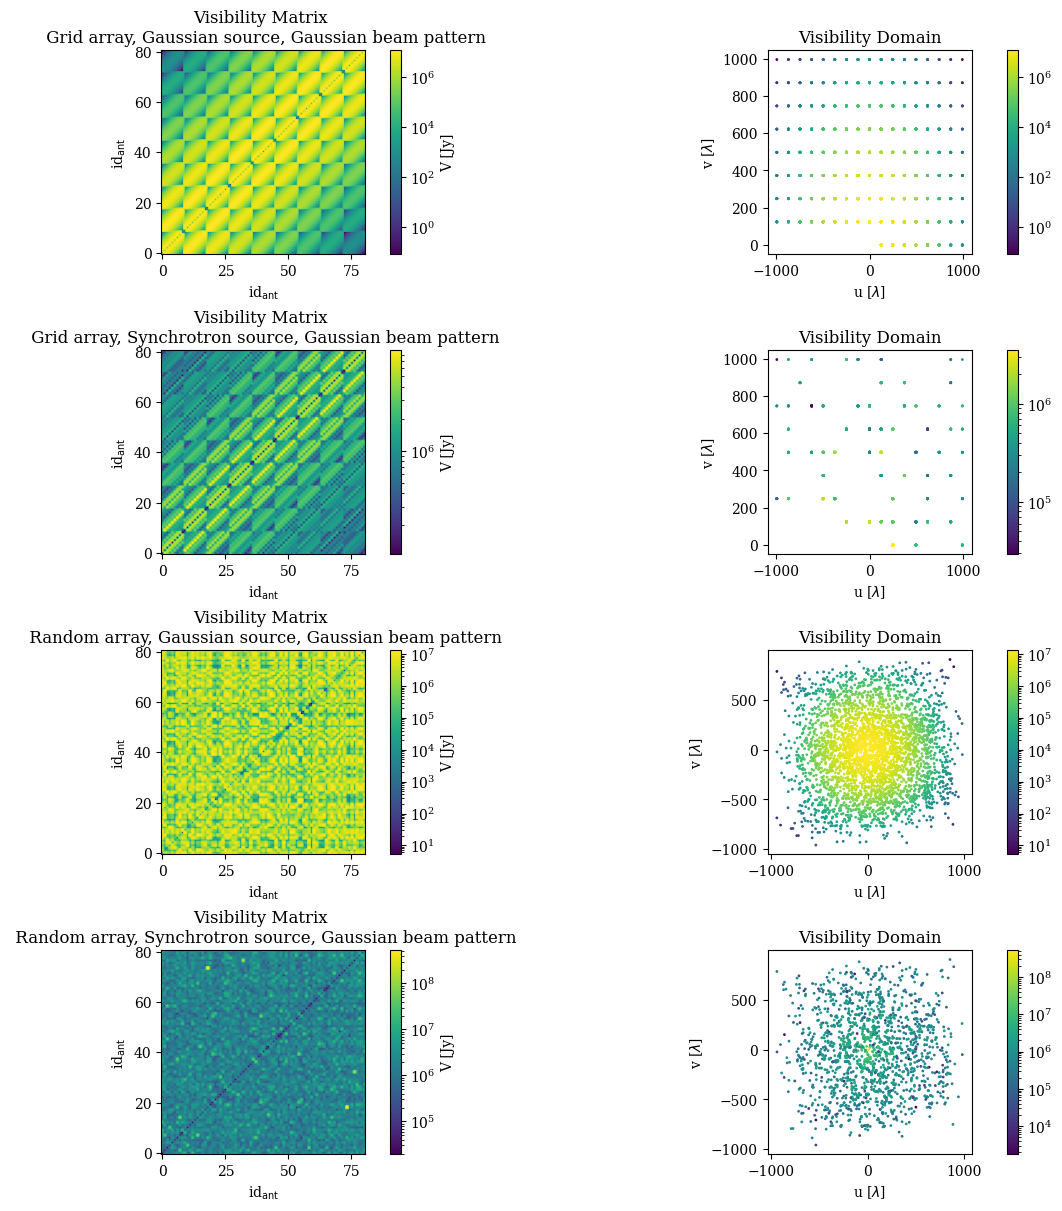

In [4]:
fig, axes= plt.subplots(4, 2, figsize=(12, 12), constrained_layout= True)

rshift=8.52

vis_list0, vis_mx0, bas_coord0= visibility_matrix_func(xyz_grid, lmn_coord, rshift, gaussian_source, beam_pattern)
im00 = axes[0,0].imshow(np.abs(vis_mx0), origin='lower', cmap='viridis', norm=LogNorm())
axes[0,0].set_xlabel(r'id$_\mathrm{ant}$')
axes[0,0].set_ylabel(r'id$_\mathrm{ant}$')
axes[0,0].set_title('Visibility Matrix \n Grid array, Gaussian source, Gaussian beam pattern')
plt.colorbar(im00, ax=axes[0,0], label='V [Jy]')

im01= axes[0,1].scatter(x=bas_coord0[:,0], y=bas_coord0[:,1], c=vis_list0.real, s=1, norm=LogNorm())
axes[0,1].set_xlabel(r'u [$\lambda$]')
axes[0,1].set_ylabel(r'v [$\lambda$]')
axes[0,1].set_title('Visibility Domain')
axes[0,1].set_box_aspect(1)
plt.colorbar(im01, ax=axes[0,1])


vis_list1, vis_mx1, bas_coord1= visibility_matrix_func(xyz_grid, lmn_coord, rshift, synchro_source, beam_pattern)
im10 = axes[1,0].imshow(np.abs(vis_mx1), origin='lower', cmap='viridis', norm=LogNorm())
axes[1,0].set_xlabel(r'id$_\mathrm{ant}$')
axes[1,0].set_ylabel(r'id$_\mathrm{ant}$')
axes[1,0].set_title('Visibility Matrix \n Grid array, Synchrotron source, Gaussian beam pattern')
plt.colorbar(im10, ax=axes[1,0], label='V [Jy]')

im11= axes[1,1].scatter(x=bas_coord1[:,0], y=bas_coord1[:,1], c=vis_list1.real, s=1, norm=LogNorm())
axes[1,1].set_xlabel(r'u [$\lambda$]')
axes[1,1].set_ylabel(r'v [$\lambda$]')
axes[1,1].set_title('Visibility Domain')
axes[1,1].set_box_aspect(1)
plt.colorbar(im11, ax=axes[1,1])


vis_list2, vis_mx2, bas_coord2= visibility_matrix_func(xyz_random, lmn_coord, rshift, gaussian_source, beam_pattern)
im20 = axes[2,0].imshow(np.abs(vis_mx2), origin='lower', cmap='viridis', norm=LogNorm())
axes[2,0].set_xlabel(r'id$_\mathrm{ant}$')
axes[2,0].set_ylabel(r'id$_\mathrm{ant}$')
axes[2,0].set_title('Visibility Matrix \n Random array, Gaussian source, Gaussian beam pattern')
plt.colorbar(im20, ax=axes[2,0], label='V [Jy]')

im21= axes[2,1].scatter(x=bas_coord2[:,0], y=bas_coord2[:,1], c=vis_list2.real, s=1, norm=LogNorm())
axes[2,1].set_xlabel(r'u [$\lambda$]')
axes[2,1].set_ylabel(r'v [$\lambda$]')
axes[2,1].set_title('Visibility Domain')
axes[2,1].set_box_aspect(1)
plt.colorbar(im21, ax=axes[2,1])


vis_list3, vis_mx3, bas_coord3= visibility_matrix_func(xyz_random, lmn_coord, rshift, synchro_source, beam_pattern)
im30 = axes[3,0].imshow(np.abs(vis_mx3), origin='lower', cmap='viridis', norm=LogNorm())
axes[3,0].set_xlabel(r'id$_\mathrm{ant}$')
axes[3,0].set_ylabel(r'id$_\mathrm{ant}$')
axes[3,0].set_title('Visibility Matrix \n Random array, Synchrotron source, Gaussian beam pattern')
plt.colorbar(im30, ax=axes[3,0], label='V [Jy]')

im31= axes[3,1].scatter(x=bas_coord3[:,0], y=bas_coord3[:,1], c=vis_list3.real, s=1, norm=LogNorm())
axes[3,1].set_xlabel(r'u [$\lambda$]')
axes[3,1].set_ylabel(r'v [$\lambda$]')
axes[3,1].set_title('Visibility Domain')
axes[3,1].set_box_aspect(1)
plt.colorbar(im31, ax=axes[3,1])

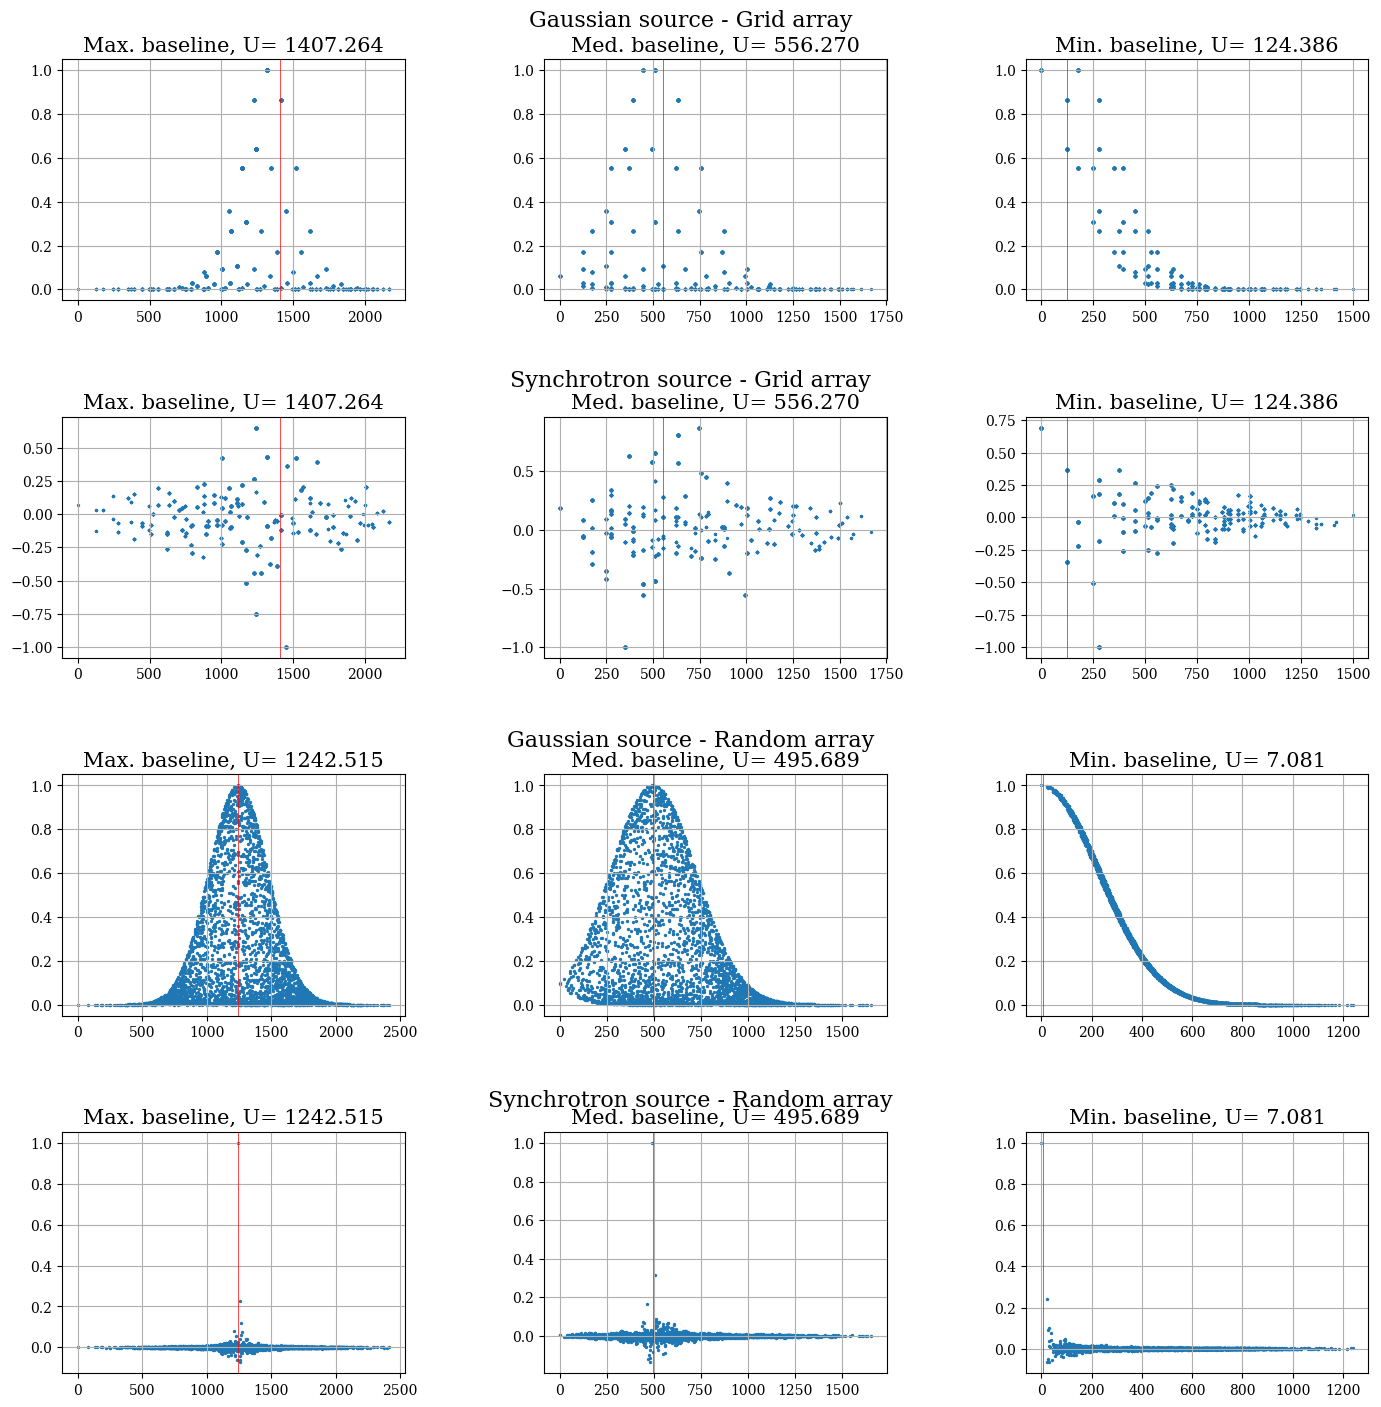

In [5]:
visibilities_list= [vis_list0, vis_list1, vis_list2, vis_list3]
baselines_list= [bas_coord0, bas_coord1, bas_coord2, bas_coord3]

titles_source= ["Gaussian", "Synchrotron", "Gaussian", "Synchrotron"]
titles_grid= ["Grid", "Grid", "Random", "Random"]
plot_title= ["Max. baseline", "Med. baseline", "Min. baseline"]

freq = t2c.cosmo.z_to_nu(rshift) * 10**6
lam = cst.c.value / freq
D= 45

fig, axes= plt.subplots(4, 3, figsize=(15, 15), constrained_layout= True)

for i in range(len(visibilities_list)):
    baselines_list_norm= np.linalg.norm(baselines_list[i], axis=1)

    i_max= np.argmax(baselines_list_norm) #Find the index of the vector with the largest norm
    i_min= np.argmin(baselines_list_norm) #Find the index of the vector with the smallest norm
    i_med= median_index(baselines_list_norm) #Find the index of the vector with the median value

    maxmedmin_index= [i_max, i_med, i_min]

    row_title = f"{titles_source[i]} source - {titles_grid[i]} array"
    fig.text(0.5, 0.96 - i * 0.24, row_title, ha='center', fontsize=16)

    for j, index in enumerate(maxmedmin_index):
        vis_corr, baseline_dist_norm= visibility_correlation_func(index, baselines_list[i], visibilities_list[i], len(visibilities_list[i]))
        max_vis_corr= np.max(np.abs(vis_corr))
        axes[i, j].scatter(baseline_dist_norm, vis_corr/ max_vis_corr, s=2)
        axes[i, j].set_title(plot_title[j]+", U= %1.3f" % baselines_list_norm[index], fontsize=15)
        axes[i, j].axvline(baselines_list_norm[index], color='r', lw=0.5)
        #axes[i, j].axvline(2*D/lam, color='k', lw=5)
        axes[i, j].grid()

plt.tight_layout(pad=5.0)
plt.show()

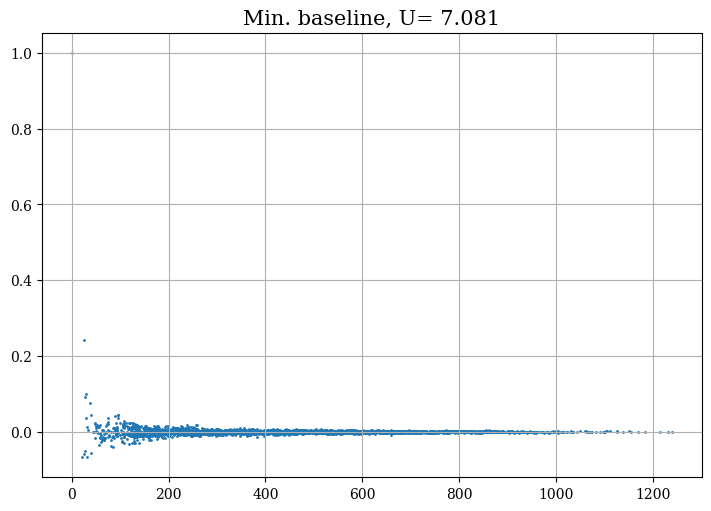

In [6]:
fig, axes= plt.subplots(1, 1, figsize=(7, 5), constrained_layout= True)

baselines_list_norm= np.linalg.norm(bas_coord3, axis=1)
i_min= np.argmin(baselines_list_norm)

vis_corr, baseline_dist_norm= visibility_correlation_func(i_min, bas_coord3, vis_list3, len(vis_list3))
max_vis_corr= np.max(np.abs(vis_corr))

axes.scatter(baseline_dist_norm, vis_corr/ max_vis_corr, s=1)
axes.set_title("Min. baseline, U= %1.3f" % baselines_list_norm[i_min], fontsize=15)
axes.grid()

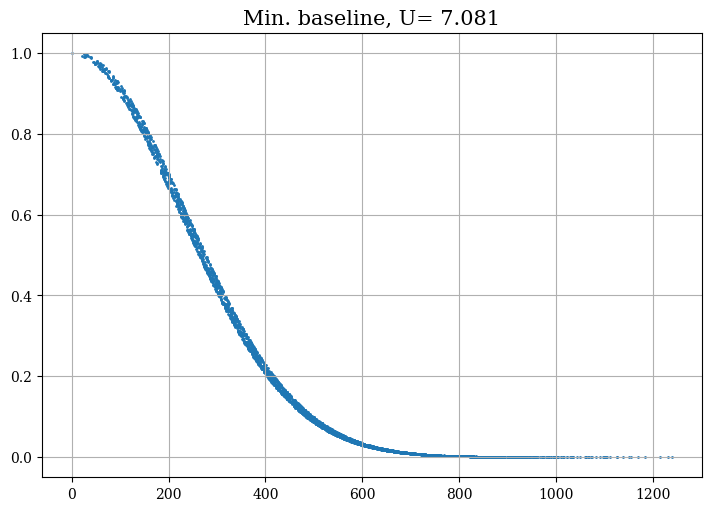

In [7]:
fig, axes= plt.subplots(1, 1, figsize=(7, 5), constrained_layout= True)

baselines_list_norm= np.linalg.norm(bas_coord2, axis=1)
i_min= np.argmin(baselines_list_norm)

vis_corr, baseline_dist_norm= visibility_correlation_func(i_min, bas_coord2, vis_list2, len(vis_list2))
max_vis_corr= np.max(np.abs(vis_corr))


axes.scatter(baseline_dist_norm, vis_corr/ max_vis_corr, s=1)
axes.set_title("Min. baseline, U= %1.3f" % baselines_list_norm[i_min], fontsize=15)
axes.grid()

***
## __Plotting the theoretical primary beam and its Gaussian approximation in real and Fourier space.__

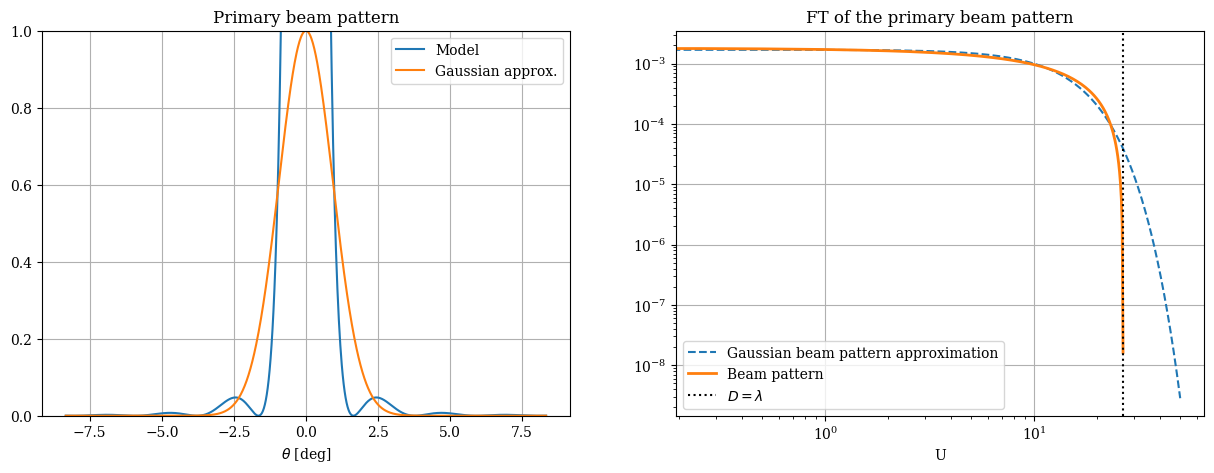

In [8]:
def primary_beam_pattern(theta, D=45, z=7):
    freq = t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    return ((2*lam / (np.pi*theta*D)) * jv(0, np.pi*theta*D/lam))**2

def gaussian_beam_pattern(theta, D=45, z=7):
    freq = t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6*fwhm

    return np.exp(-theta**2 / theta_0**2)

def primary_beam_pattern_FT(U, D=45, z=7):
    freq = t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    const=(8 * lam**4)/ (np.pi**2 * D**4)

    return const*( (D/lam)**2 * np.arccos(lam*U/D) - U*np.sqrt((D/lam)**2 - U**2))

def gaussian_beam_pattern_FT(U, D=45, z=7):
    freq = t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    U_0 = 0.53 / fwhm

    return np.exp(-U**2 / U_0**2) / (np.pi * U_0**2)

theta = np.linspace(-500.*u.arcmin, 500.*u.arcmin, 1000).to('rad').value
U= np.linspace(0, 50, 200)
freq = t2c.cosmo.z_to_nu(7) * 10**6
lam = cst.c.value / freq
D=45

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(np.rad2deg(theta), primary_beam_pattern(theta), label='Model')
axes[0].plot(np.rad2deg(theta), gaussian_beam_pattern(theta), label= 'Gaussian approx.')
axes[0].set_xlabel(r'$\theta$ [deg]')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].set_title('Primary beam pattern')
axes[0].grid()

axes[1].plot(U, gaussian_beam_pattern_FT(U), linestyle= 'dashed', label='Gaussian beam pattern approximation')
axes[1].plot(U, primary_beam_pattern_FT(U), label= 'Beam pattern', linewidth=2)
axes[1].axvline(D / lam, label= r'$D=\lambda$', linestyle='dotted', color='k')
axes[1].set_xlabel('U')
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].set_title('FT of the primary beam pattern')
axes[1].grid()

***
## __Choudhuri visibility correlation functions__

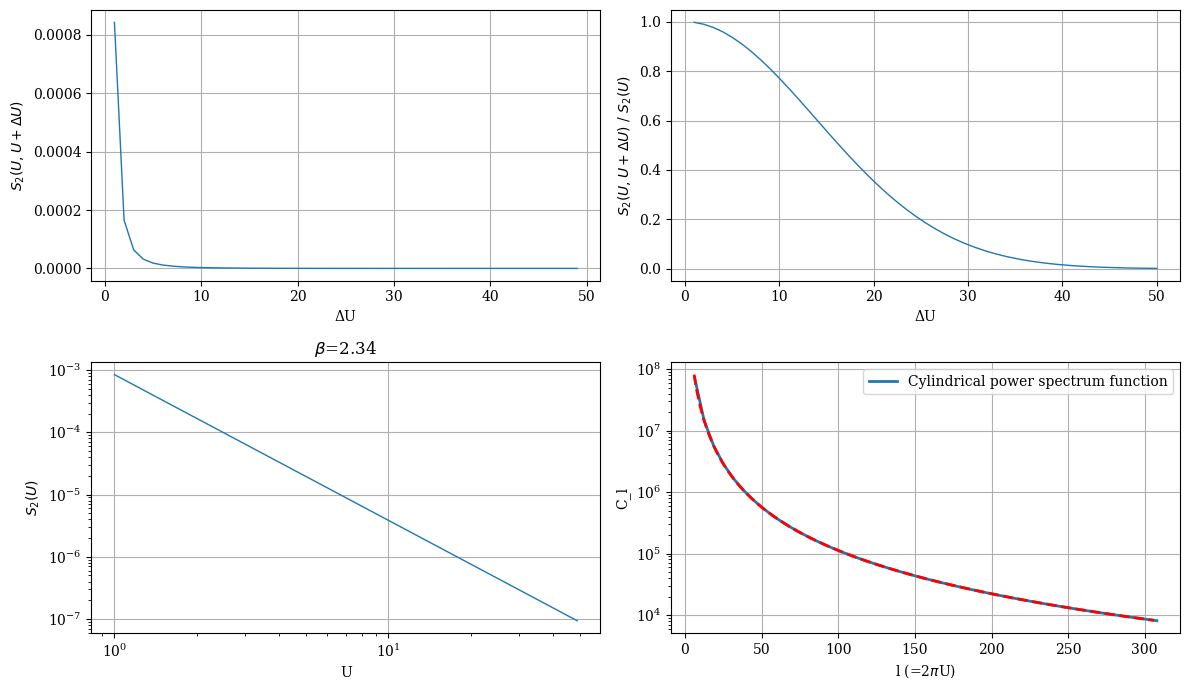

In [9]:
def S2_delta_U(U, delta_U, A, z=7, beta= 2.34, D=45):
    freq= t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6* fwhm
    sigma_0 = 0.76 / fwhm
    
    const = (np.pi * theta_0**2) / 2
    S2= const * A * U**(-beta)

    return S2, S2 * np.exp(-(np.abs(delta_U) / sigma_0)**2)

def cyl_powerspec(l_cb, beta=2.34, A150= 513):
    return A150*(1000/l_cb)**beta

def cyl_from_S2(S2, z=7, D=45):
    freq = t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    theta_0 = 0.6 * fwhm
    sigma_0 = 0.76 / fwhm

    dBdT = 2 * cst.k_B.value / (lam**2)
    const = (np.pi * theta_0**2) / 2

    return S2 / (const * dBdT**2)

U = np.arange(1, 50, 1)
delta_U = np.linspace(1, 50, len(U))
l_cb = np.arange(int(2*np.pi*U[0]), int(2*np.pi*U[-1]) , 1)

S2, S2_del = S2_delta_U(U, delta_U, A=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(U, S2_del, linewidth=1)
axes[0, 0].set_xlabel("ΔU")
axes[0, 0].set_ylabel("$S_2(U, U+ΔU)$")
axes[0, 0].grid()

axes[0, 1].plot(delta_U, S2_del/ S2, linewidth=1)
axes[0, 1].set_xlabel("ΔU")
axes[0, 1].set_ylabel("$S_2(U, U+ΔU)$ / $S_2(U)$")
axes[0, 1].grid()

axes[1, 0].plot(U, S2, linewidth=1)
axes[1, 0].set_title(r"$\beta$=2.34")
axes[1, 0].set_xlabel("U")
axes[1, 0].set_ylabel(r"$S_2(U)$")
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].grid()

axes[1, 1].plot(2*np.pi*U, cyl_powerspec(2*np.pi*U), linewidth= 2, label="Cylindrical power spectrum function")
axes[1, 1].plot(l_cb, cyl_powerspec(l_cb), linewidth= 2, color= 'red', linestyle='dashed')
axes[1, 1].set_xlabel(r"l (=2$\pi$U)")
axes[1, 1].set_ylabel(r"C_l")
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid()

plt.tight_layout()
plt.show()

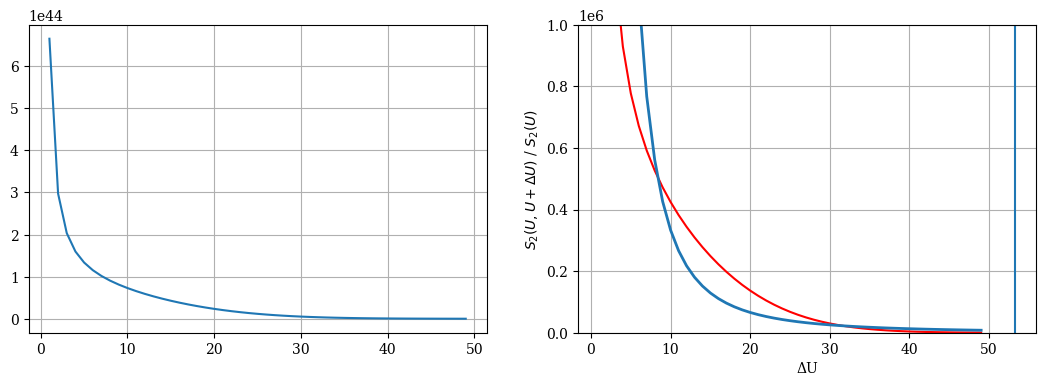

In [10]:
extract = cyl_from_S2(S2_del, delta_U)
scale= np.mean(extract/ cyl_powerspec(2*np.pi*U))

freq = t2c.cosmo.z_to_nu(7) * 10**6
lam = cst.c.value / freq

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(U, extract)
axes[0].grid()

axes[1].plot(U, extract/scale, color='r')
axes[1].plot(U, cyl_powerspec(2*np.pi*U), linewidth= 2, label="Cylindrical power spectrum function")
axes[1].axvline(2*D / lam)
axes[1].set_xlabel("ΔU")
axes[1].set_ylabel("$S_2(U, U+ΔU)$ / $S_2(U)$")
axes[1].set_ylim(0, 10**6)
axes[1].grid()

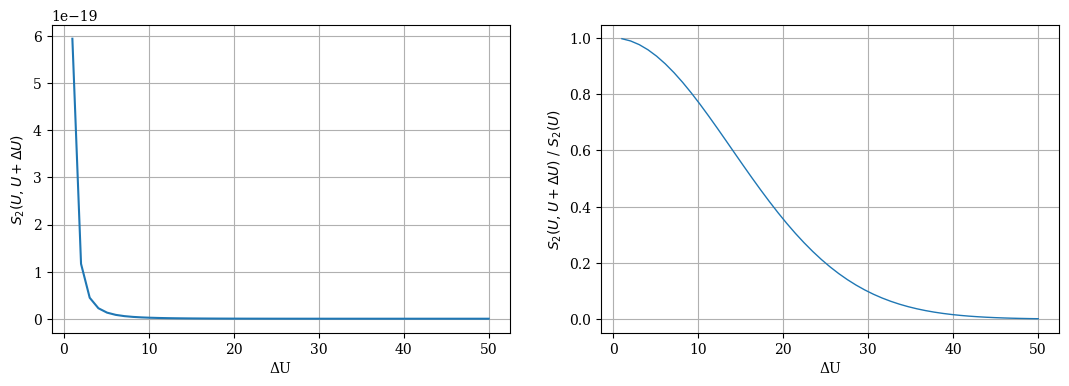

In [11]:
def S2_full(U, delta_U, z=7, beta= 2.34, D=45):
    freq= t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6* fwhm
    sigma_0 = 0.76 / fwhm

    const = (np.pi * theta_0**2) / 2
    dBdT = 2 * cst.k_B.value / (lam**2)
    exp = np.exp(- (delta_U / sigma_0)**2)

    A150 = 513
    C_l = A150 * (1000 / (2*np.pi*U))**beta

    return const * dBdT * exp * C_l, exp

U = np.arange(1, 50, 1)
delta_U = np.linspace(1, 50, len(U))

S2_del, exp = S2_full(U, delta_U)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(delta_U, S2_del)
axes[0].set_xlabel("ΔU")
axes[0].set_ylabel("$S_2(U, U+ΔU)$")
axes[0].grid()

axes[1].plot(delta_U, exp, linewidth=1)
axes[1].set_xlabel("ΔU")
axes[1].set_ylabel("$S_2(U, U+ΔU)$ / $S_2(U)$")
axes[1].grid()

7.042727615697551e-06
2.34


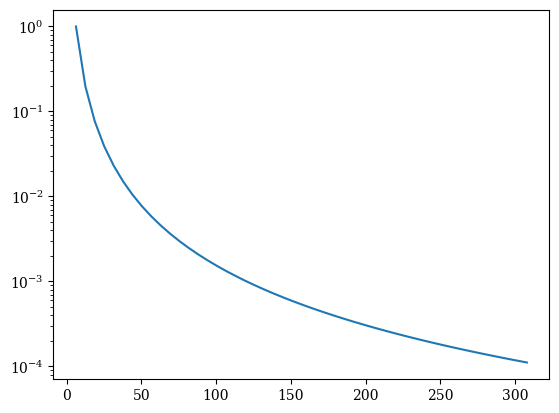

In [12]:
y = cyl_from_S2(S2, z=7, D=45)
y /= np.max(y)

plt.plot(2*np.pi*U, y)
plt.yscale('log')

def func(x , A, beta):
    return A * (1000/ x)**beta

A=1
b=3

#Curve fitting
popt, pcov= curve_fit(func, 2*np.pi*U, y)

A_optimized, b_optimized = popt

print(A_optimized)
print(b_optimized)

In [13]:
visibility_pair_combs= list(itertools.combinations(range(N_B), 2))
visibility_correlations= np.empty(len(visibility_pair_combs), dtype=np.complex128)
baseline_distances= np.empty((len(visibility_pair_combs), xyz_coord.shape[1]))

for i in tqdm(range(len(visibility_pair_combs))):
    ii, jj = visibility_pair_combs[i]
    visibility_correlations[i] = visibility_list[ii] * np.conj(visibility_list[jj])

    baseline_distances[i]= baselines_coord[jj] - baselines_coord[ii]

baseline_distances_norm= np.linalg.norm(baseline_distances, axis=1)

visibility_correlations_norm= np.abs(visibility_correlations)
max_visibility= np.max(visibility_correlations_norm)
visibility_correlations_norm= visibility_correlations_norm/ max_visibility

plt.scatter(baseline_distances_norm, visibility_correlations_norm, s=2)
plt.xlabel("ΔU")
plt.ylabel("Normalised visibility correlation")

NameError: name 'N_B' is not defined

***
## __Plotting the layout, visibility matrix and baselines correlation for GMRT array.__

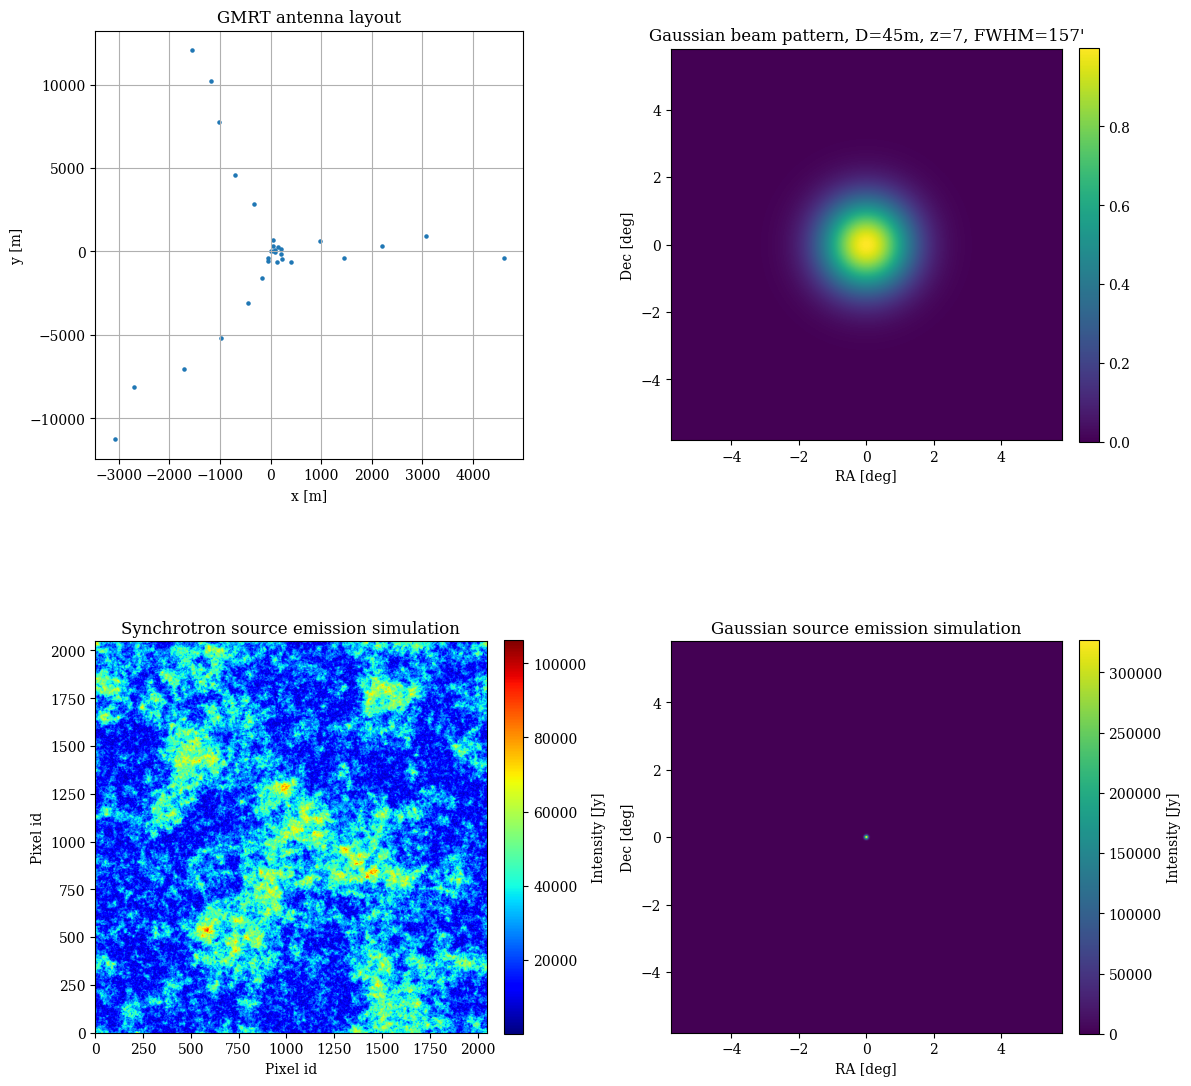

In [27]:
FoV= 2*5.8*u.deg

thet= np.linspace(-FoV/2, FoV/2, 2048).to('rad').value
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
ang_dim_dist= FoV.to('rad').value * cosmo.angular_diameter_distance(rshift).value 

#***********************************************
gmrt_layout = np.loadtxt('gmrt_layout.txt')
#Remove the z-coordinates from the layout:
gmrt_layout= gmrt_layout[:,:-1]
#***********************************************

#Gaussian and synchrotron sources, beam pattern
gaussian_source= gaussian_source_2d(l_coord, m_coord, [0.1, 0.1])
synchro_source, l= galactic_synch_fg_custom(z=[rshift], ncells=len(thet), boxsize=ang_dim_dist, rseed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord)

#Plotting the sources and the layout
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0,0].scatter(gmrt_layout[:,0], gmrt_layout[:,1], s=5, color='tab:blue')
axes[0,0].set_title("GMRT antenna layout")
axes[0,0].set_ylabel('y [m]')
axes[0,0].set_xlabel('x [m]')
axes[0,0].set_box_aspect(1)
axes[0,0].grid()

im0 = axes[0,1].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), beam_pattern, cmap='viridis')
axes[0,1].set_ylabel('Dec [deg]')
axes[0,1].set_xlabel('RA [deg]')
axes[0,1].set_title("Gaussian beam pattern, D=45m, z=7, FWHM=157'")
axes[0,1].set_box_aspect(1)
plt.colorbar(im0, fraction=0.046, pad=0.04)

im1 = axes[1,0].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[1,0].set_title("Synchrotron source emission simulation")
axes[1,0].set_ylabel('Pixel id')
axes[1,0].set_xlabel('Pixel id')
axes[1,0].set_box_aspect(1)
plt.colorbar(im1, label='Intensity [Jy]', fraction=0.046, pad=0.04)

im2 = axes[1,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, gaussian_source, cmap='viridis')
axes[1,1].set_title('Gaussian source emission simulation')
axes[1,1].set_ylabel('Dec [deg]')
axes[1,1].set_xlabel('RA [deg]')
axes[1,1].set_box_aspect(1)
plt.colorbar(im2, label='Intensity [Jy]', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

100%|██████████| 435/435 [04:35<00:00,  1.58it/s]


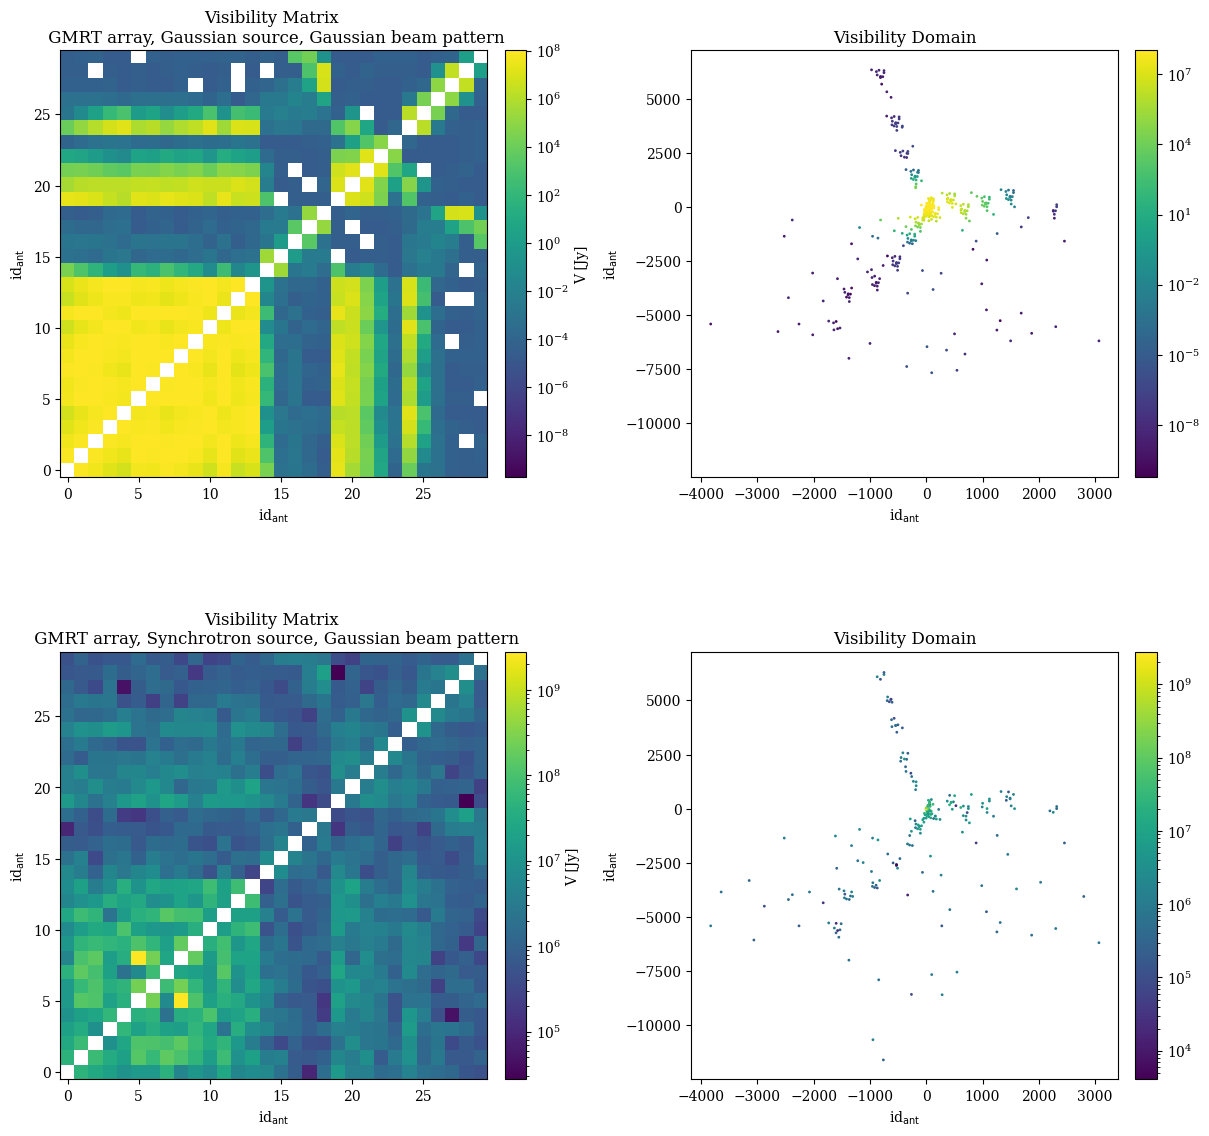

In [28]:
fig, axes= plt.subplots(2, 2, figsize=(12, 12), constrained_layout= True)

vis_list_gmrt0, vis_mx_gmrt0, bas_coord_gmrt0= visibility_matrix_func(gmrt_layout, lmn_coord, rshift, gaussian_source, beam_pattern)
im00 = axes[0,0].imshow(np.abs(vis_mx_gmrt0), origin='lower', cmap='viridis', norm=LogNorm())
axes[0,0].set_xlabel(r'id$_\mathrm{ant}$')
axes[0,0].set_ylabel(r'id$_\mathrm{ant}$')
axes[0,0].set_title('Visibility Matrix \n GMRT array, Gaussian source, Gaussian beam pattern')
plt.colorbar(im00, ax=axes[0,0], label='V [Jy]', fraction=0.05, pad=0.04)

im01= axes[0,1].scatter(x=bas_coord_gmrt0[:,0], y=bas_coord_gmrt0[:,1], c=vis_list_gmrt0.real, s=1, norm=LogNorm())
axes[0,1].set_xlabel(r'id$_\mathrm{ant}$')
axes[0,1].set_ylabel(r'id$_\mathrm{ant}$')
axes[0,1].set_title('Visibility Domain')
axes[0,1].set_box_aspect(1)
plt.colorbar(im01, ax=axes[0,1], fraction=0.05, pad=0.04)

vis_list_gmrt1, vis_mx_gmrt1, bas_coord_gmrt1= visibility_matrix_func(gmrt_layout, lmn_coord, rshift, synchro_source, beam_pattern)
im10 = axes[1,0].imshow(np.abs(vis_mx_gmrt1), origin='lower', cmap='viridis', norm=LogNorm())
axes[1,0].set_xlabel(r'id$_\mathrm{ant}$')
axes[1,0].set_ylabel(r'id$_\mathrm{ant}$')
axes[1,0].set_title('Visibility Matrix \n GMRT array, Synchrotron source, Gaussian beam pattern')
plt.colorbar(im10, ax=axes[1,0], label='V [Jy]', fraction=0.05, pad=0.04)

im11= axes[1,1].scatter(x=bas_coord_gmrt1[:,0], y=bas_coord_gmrt1[:,1], c=vis_list_gmrt1.real, s=1, norm=LogNorm())
axes[1,1].set_xlabel(r'id$_\mathrm{ant}$')
axes[1,1].set_ylabel(r'id$_\mathrm{ant}$')
axes[1,1].set_title('Visibility Domain')
axes[1,1].set_box_aspect(1)
plt.colorbar(im11, ax=axes[1,1], fraction=0.05, pad=0.04)

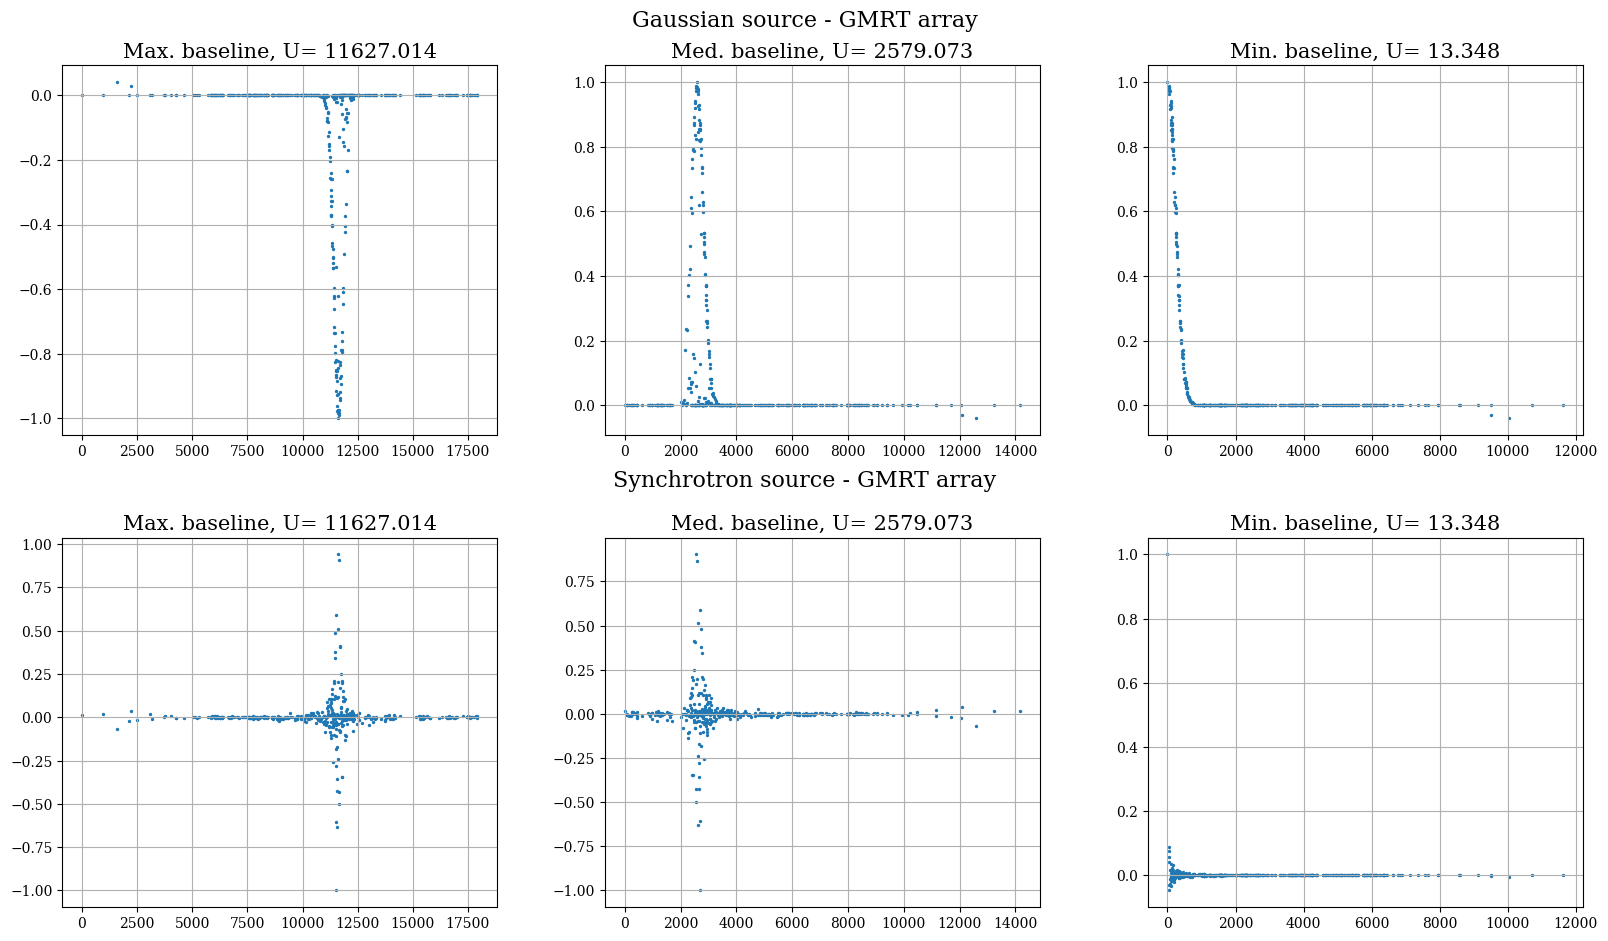

In [29]:
gmrt_vis_list= [vis_list_gmrt0, vis_list_gmrt1]
gmrt_bas_list= [bas_coord_gmrt0, bas_coord_gmrt1]

titles= ["Gaussian", "Synchrotron"]
plot_title= ["Max. baseline", "Med. baseline", "Min. baseline"]

#N_ant= len(gmrt_layout)
#N_B= N_ant* (N_ant - 1) /2

fig, axes= plt.subplots(2, 3, figsize=(17, 10), constrained_layout= True)

for i in range(len(gmrt_vis_list)):
    gmrt_bas_norm= np.linalg.norm(gmrt_bas_list[i], axis=1)

    i_max= np.argmax(gmrt_bas_norm)
    i_min= np.argmin(gmrt_bas_norm)
    i_med= median_index(gmrt_bas_norm)

    maxmedmin_index= [i_max, i_med, i_min]

    row_title = f"{titles[i]} source - GMRT array"
    fig.text(0.5, 0.96 - i * 0.46, row_title, ha='center', fontsize=16)

    for j, index in enumerate(maxmedmin_index):
        vis_corr, baseline_dist_norm= visibility_correlation_func(index, gmrt_bas_list[i], gmrt_vis_list[i], len(gmrt_vis_list[i]))
        max_vis_corr= np.max(np.abs(vis_corr))
        axes[i, j].scatter(baseline_dist_norm, vis_corr/ max_vis_corr, s=2)
        axes[i, j].set_title(plot_title[j]+", U= %1.3f" % gmrt_bas_norm[index], fontsize=15)
        axes[i, j].grid()

plt.tight_layout(pad=4.0)
plt.show()

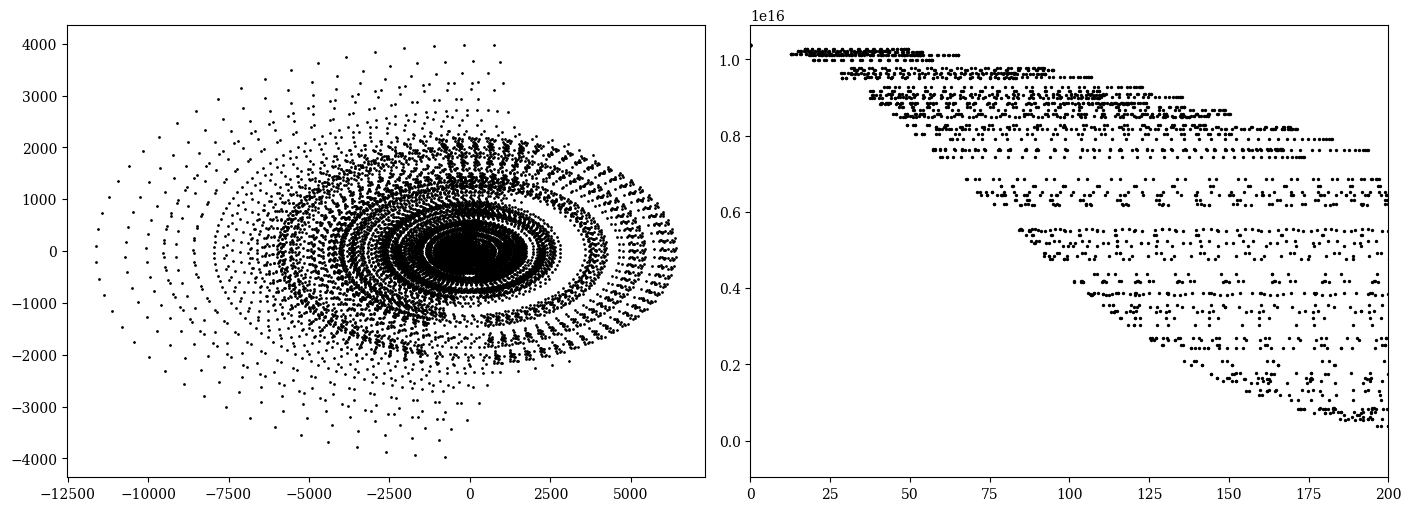

In [30]:
fig, axes= plt.subplots(1, 2, figsize= (14, 5), constrained_layout=True)

bas_coord_gmrt0

dec= 20. * u.deg #Declination
time_steps= 40
h_angle = np.linspace(-6, 6, num=time_steps) * u.hourangle

for i_t, h in enumerate(h_angle):
    rotation_matrix= Earth_Rotation_Effect(HA=h, delta=dec)
    baseline_rot= np.dot(rotation_matrix, bas_coord_gmrt0.T).T
    
    axes[0].scatter(baseline_rot[:,0], baseline_rot[:,1], s=1, color='k')
    
    gmrt_bas_norm= np.linalg.norm(baseline_rot, axis=1)
    i_min= np.argmin(gmrt_bas_norm)

    vis_corr, bas_dist_norm= visibility_correlation_func(i_min, baseline_rot, vis_list_gmrt0, len(vis_list_gmrt0))
    axes[1].scatter(bas_dist_norm, vis_corr, s=2, color='k')
    axes[1].set_xlim(0, 200)

(0.0, 1.0)

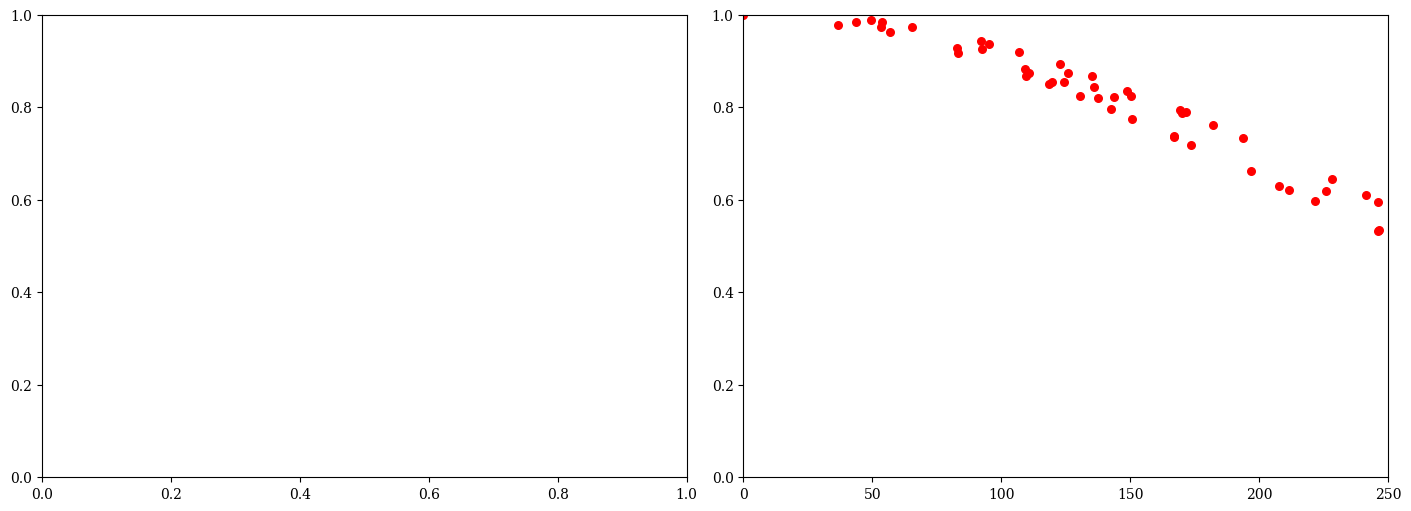

In [33]:
fig, axes= plt.subplots(1, 2, figsize= (14, 5), constrained_layout=True)

gmrt_bas_norm= np.linalg.norm(bas_coord_gmrt0, axis=1)
i_min= np.argmin(gmrt_bas_norm)
vis_corr, baseline_dist_norm= visibility_correlation_func(i_min, bas_coord_gmrt0, vis_list_gmrt0, len(vis_list_gmrt0))
max_vis_corr= np.max(vis_corr)

axes[1].scatter(baseline_dist_norm, vis_corr/ max_vis_corr, s=30, color='r')

dec= 0. * u.deg #Declination
time_steps= 40
h_angle = np.linspace(-6, 6, num=time_steps) * u.hourangle

# for i_t, h in enumerate(tqdm(h_angle)):
#     rotation_matrix= Earth_Rotation_Effect(HA=h, delta=dec)
#     baseline_rot= np.dot(rotation_matrix, bas_coord_gmrt0.T).T
    
#     axes[0].scatter(baseline_rot[:,0], baseline_rot[:,1], s=1, color='k')
    
#     gmrt_bas_norm= np.linalg.norm(baseline_rot, axis=1)
#     i_min= np.argmin(gmrt_bas_norm)

#     vis_list_rot, vis_mx_rot= visibility_rotation_synthesis(lmn_coord, baseline_rot, gaussian_source, beam_pattern, len(gmrt_layout))

#     vis_corr, bas_dist_norm= visibility_correlation_func(i_min, baseline_rot, vis_list_rot, len(vis_list_rot))

#     max_vis_corr= np.max(vis_corr)
#     axes[1].scatter(bas_dist_norm, vis_corr/ max_vis_corr, s=2, color='k')
axes[1].set_xlim(0, 250)
axes[1].set_ylim(0, 1)